# LGBM + SHAP 해석 분석

OLS 예측에서 확정한 `final_aic_features`를 사용해 LGBM을 전체 데이터로 학습하고,
SHAP으로 변수의 비선형 효과를 분해한다. OLS 해석 결과(β)와 변수별로 매칭하여
**견고한 효과 / 비선형 효과 / 선형으로 충분 / 무의미** 케이스를 분류한다.

- 입력: `../data/Finance_Final/dataset4_derived_full_with_dummies.csv`
- 설정: `../outputs/baseline/final_features.json`
- OLS 해석: `../outputs/baseline/ols_interpretation_coefficients.csv`
- 출력: `../outputs/baseline/lgbm_shap_summary.csv`, `interpretation_compare.csv`, `shap_values.npy`, PNG 3종

## 1. 설정 로드 + 데이터 준비

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import shap
from sklearn.metrics import r2_score, mean_squared_error

DATA_PATH = Path('../data/Finance_Final/dataset4_derived_full_with_dummies.csv')
BASELINE_DIR = Path('../outputs/baseline')
CFG_PATH = BASELINE_DIR / 'final_features.json'
OLS_PATH = BASELINE_DIR / 'ols_interpretation_coefficients.csv'

with open(CFG_PATH) as f:
    cfg = json.load(f)

target = cfg['target']
final_aic_features = cfg['final_aic_features']
print(f'target: {target}')
print(f'n_features: {len(final_aic_features)}')
print('features:', final_aic_features)

target: oil_diff_target
n_features: 19
features: ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'oil_diff_lag1', 'oil_volatility_20', 'MA_ratio', 'MA_5_gt_MA_20', 'is_friday', 'gfc_2008_shock', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'war_2022_shock', 'war_2022_window', 'cond_opec_cut']


In [2]:
df = pd.read_csv(DATA_PATH)
needed = final_aic_features + [target]
df_model = df[needed].dropna().reset_index(drop=True)

X = df_model[final_aic_features].copy()
y = df_model[target].copy()
print('전체 표본 수:', len(df_model))
print('X shape:', X.shape, '/ y shape:', y.shape)

전체 표본 수: 4798
X shape: (4798, 19) / y shape: (4798,)


## 2. LGBM 학습 (전체 데이터, 튜닝 없음)

In [3]:
lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)
lgbm.fit(X, y)

pred = lgbm.predict(X)
r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
print(f'in-sample R²  : {r2:.4f}')
print(f'in-sample RMSE: {rmse:.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2448
[LightGBM] [Info] Number of data points in the train set: 4798, number of used features: 19
[LightGBM] [Info] Start training from score 0.007511
in-sample R²  : 0.5370
in-sample RMSE: 1.3693


## 3. SHAP 값 계산

In [4]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X)
expected_value = explainer.expected_value

print('shap_values shape:', np.array(shap_values).shape)
print('expected_value:', expected_value)

shap_values shape: (4798, 19)
expected_value: 0.007511462209641578


## 4. SHAP 요약 표

In [5]:
shap_arr = np.array(shap_values)

shap_summary = pd.DataFrame({
    'variable': final_aic_features,
    'mean_abs_shap': np.abs(shap_arr).mean(axis=0),
    'mean_shap_signed': shap_arr.mean(axis=0),
    'sign_positive_ratio': (shap_arr > 0).mean(axis=0),
})
shap_summary = shap_summary.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_summary['rank'] = np.arange(1, len(shap_summary) + 1)
shap_summary

,variable,mean_abs_shap,mean_shap_signed,sign_positive_ratio,rank
0,MA_ratio,0.149323,0.018846,0.343476,1
1,OilPrice,0.138035,0.001879,0.484785,2
2,oil_volatility_20,0.134547,-0.004528,0.539600,3
3,OilInventories,0.103924,-0.004668,0.494581,4
4,oil_diff_lag1,0.101210,-0.000926,0.520008,5
5,VIX,0.096527,0.001932,0.459775,6
6,CPE,0.092302,-0.005502,0.647978,7
7,IndustryProduction,0.070218,-0.000898,0.527303,8
8,RealInterestRate,0.067069,-0.001050,0.421634,9
9,OPECProduction,0.060063,-0.001417,0.527303,10


## 5. SHAP 시각화

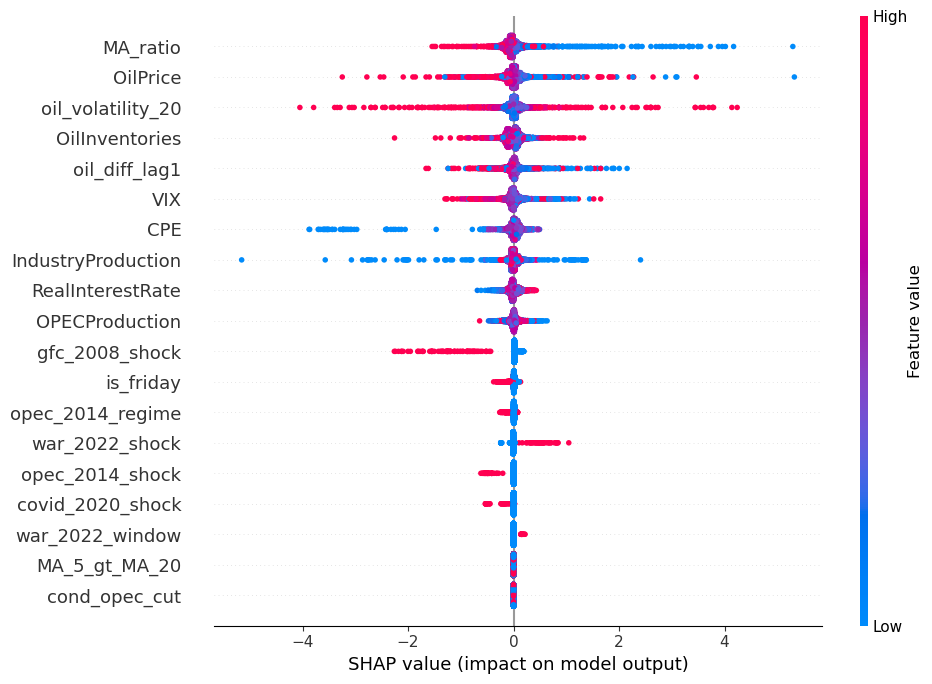

In [6]:
plt.rcParams.update({'font.size': 12})

# beeswarm
shap.summary_plot(shap_values, X, show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

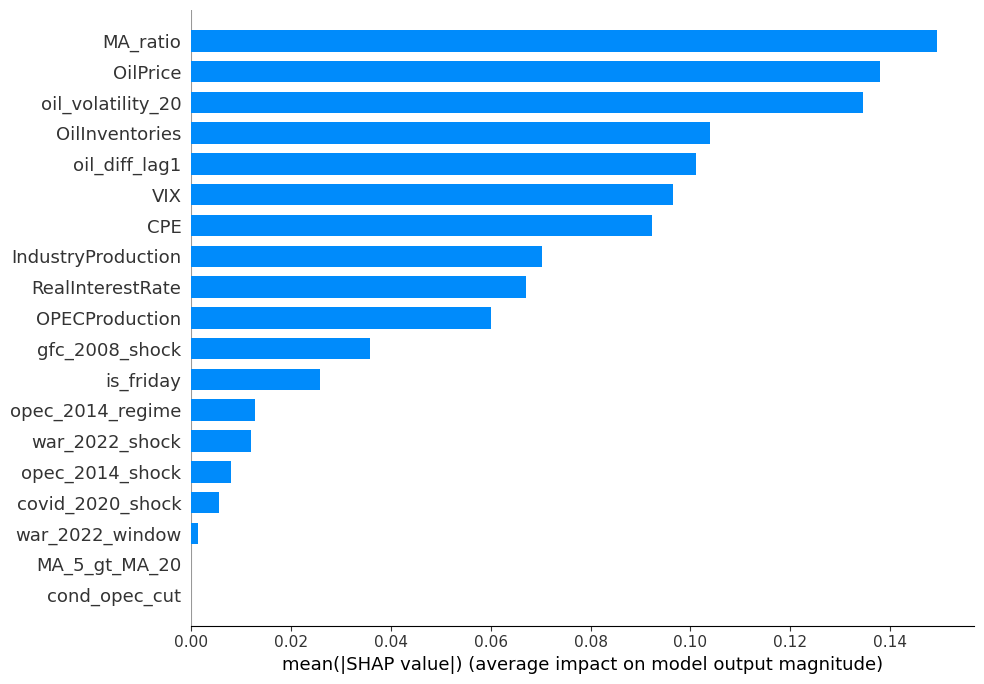

In [7]:
# bar
shap.summary_plot(shap_values, X, plot_type='bar', show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

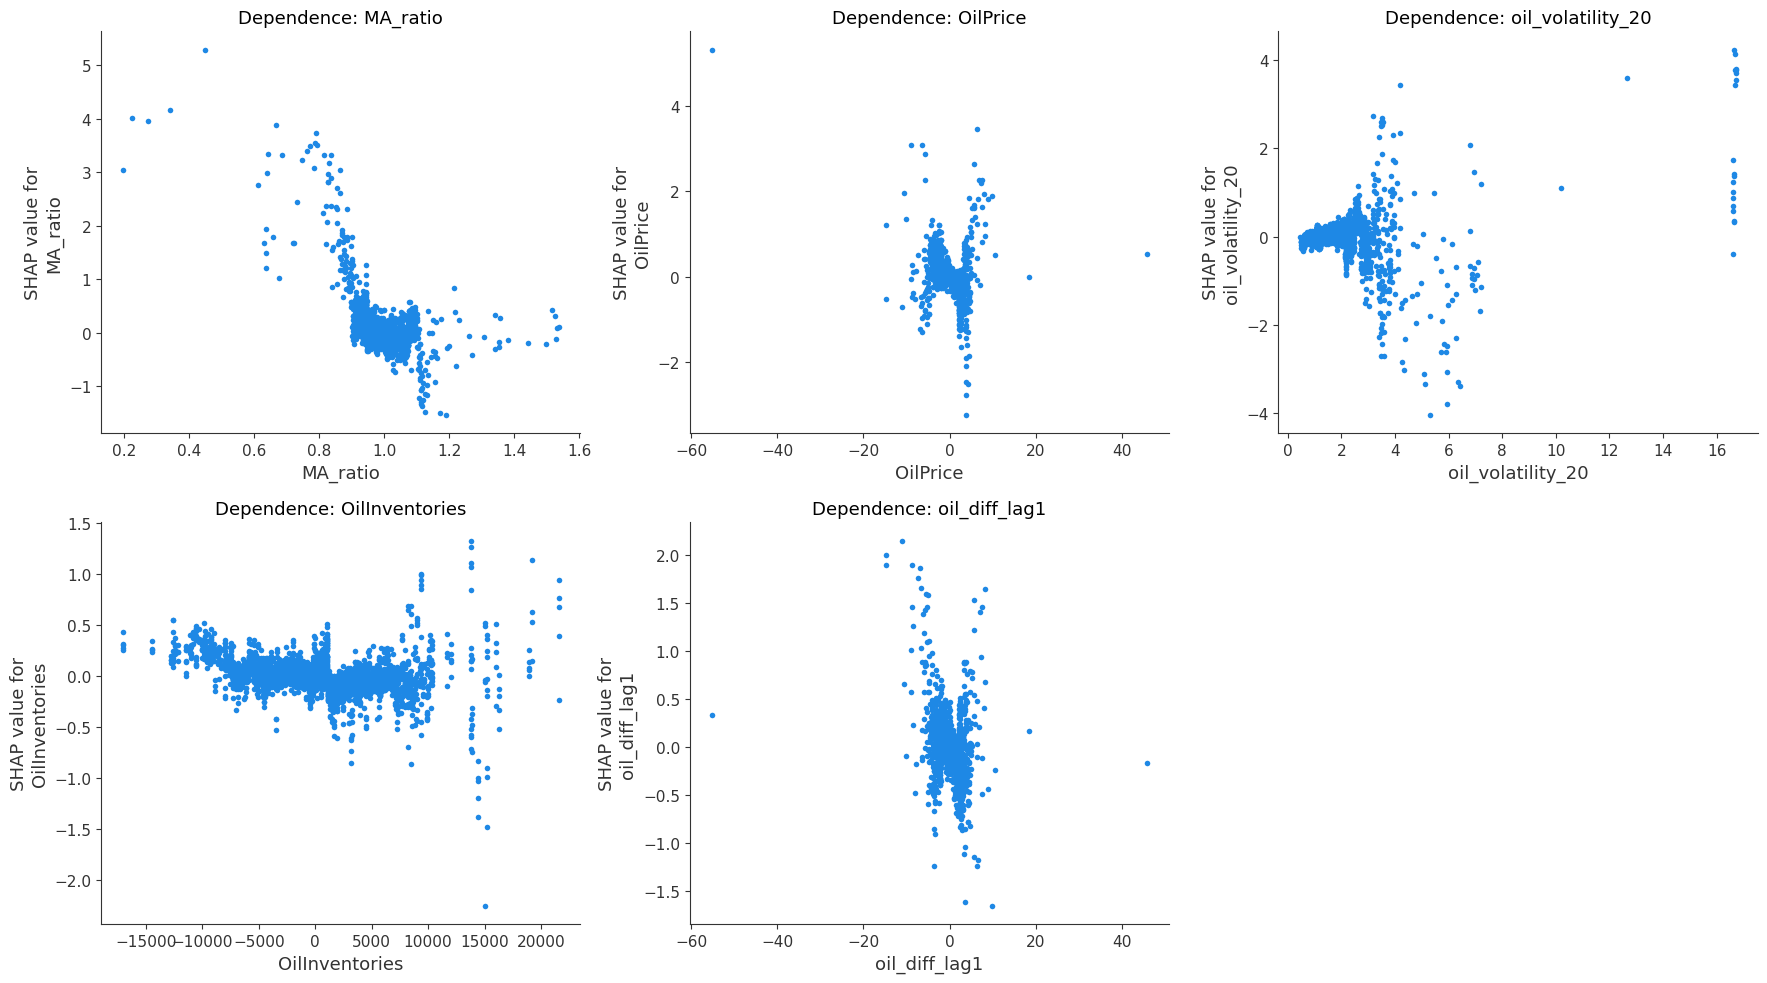

In [8]:
# 상위 5개 dependence plot
top5 = shap_summary['variable'].head(5).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, var in enumerate(top5):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'Dependence: {var}', fontsize=13)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. OLS β ↔ SHAP 비교 표

In [9]:
ols = pd.read_csv(OLS_PATH)
ols.columns = [c.lstrip('\ufeff') for c in ols.columns]
ols = ols.rename(columns={'std_beta': 'std_beta_OLS'})
ols['sig_OLS'] = ols['p_HC3'] < 0.05
ols['sign_OLS'] = np.where(ols['std_beta_OLS'] >= 0, '+', '-')

shap_for_merge = shap_summary.rename(columns={'rank': 'rank_shap'}).copy()
shap_for_merge['sign_SHAP'] = np.where(shap_for_merge['mean_shap_signed'] >= 0, '+', '-')

cmp = ols[['variable', 'std_beta_OLS', 'p_HC3', 'sig_OLS', 'sign_OLS']].merge(
    shap_for_merge[['variable', 'mean_abs_shap', 'rank_shap', 'sign_SHAP']],
    on='variable', how='inner'
)
cmp['sign_match'] = cmp['sign_OLS'] == cmp['sign_SHAP']

# top_n: 변수 19개 → 상위 1/3 ≈ 6개를 '큼'으로 정의
n_feat = len(cmp)
top_n = max(4, n_feat // 3)
shap_top_set = set(cmp.sort_values('mean_abs_shap', ascending=False).head(top_n)['variable'])
beta_top_set = set(cmp.assign(abs_beta=cmp['std_beta_OLS'].abs())
                      .sort_values('abs_beta', ascending=False).head(top_n)['variable'])

def classify(row):
    v = row['variable']
    shap_big = v in shap_top_set
    beta_big = v in beta_top_set
    sig = row['sig_OLS']
    match = row['sign_match']
    if (not sig) and shap_big:
        return '순수 비선형 효과'
    if not match:
        return '상호작용 의심'
    if shap_big and beta_big:
        return '견고한 효과'
    if shap_big and not beta_big:
        return '비선형 추가 효과'
    if beta_big and not shap_big:
        return '선형 효과 위주'
    return '약한 효과'

cmp['case'] = cmp.apply(classify, axis=1)
cmp = cmp.sort_values('rank_shap').reset_index(drop=True)
cmp

,variable,std_beta_OLS,p_HC3,sig_OLS,sign_OLS,mean_abs_shap,rank_shap,sign_SHAP,sign_match,case
0,MA_ratio,-0.371292,0.047268,True,-,0.149323,1,+,False,상호작용 의심
1,OilPrice,-0.310233,0.260299,False,-,0.138035,2,+,False,순수 비선형 효과
2,oil_volatility_20,0.159637,0.204171,False,+,0.134547,3,-,False,순수 비선형 효과
3,OilInventories,-0.079703,0.007347,True,-,0.103924,4,-,True,비선형 추가 효과
4,oil_diff_lag1,-0.126802,0.053867,False,-,0.101210,5,-,True,순수 비선형 효과
5,VIX,-0.076236,0.070366,False,-,0.096527,6,+,False,순수 비선형 효과
6,CPE,0.272013,0.006196,True,+,0.092302,7,-,False,상호작용 의심
7,IndustryProduction,-0.132410,0.226879,False,-,0.070218,8,-,True,약한 효과
8,RealInterestRate,0.072186,0.032782,True,+,0.067069,9,-,False,상호작용 의심
9,OPECProduction,-0.081208,0.346946,False,-,0.060063,10,-,True,약한 효과


## 7. 양면 bar chart (paired importance)

/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12537/937111570.py:21: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12537/937111570.py:21: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12537/937111570.py:21: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12537/937111570.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12537/937111570.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_12

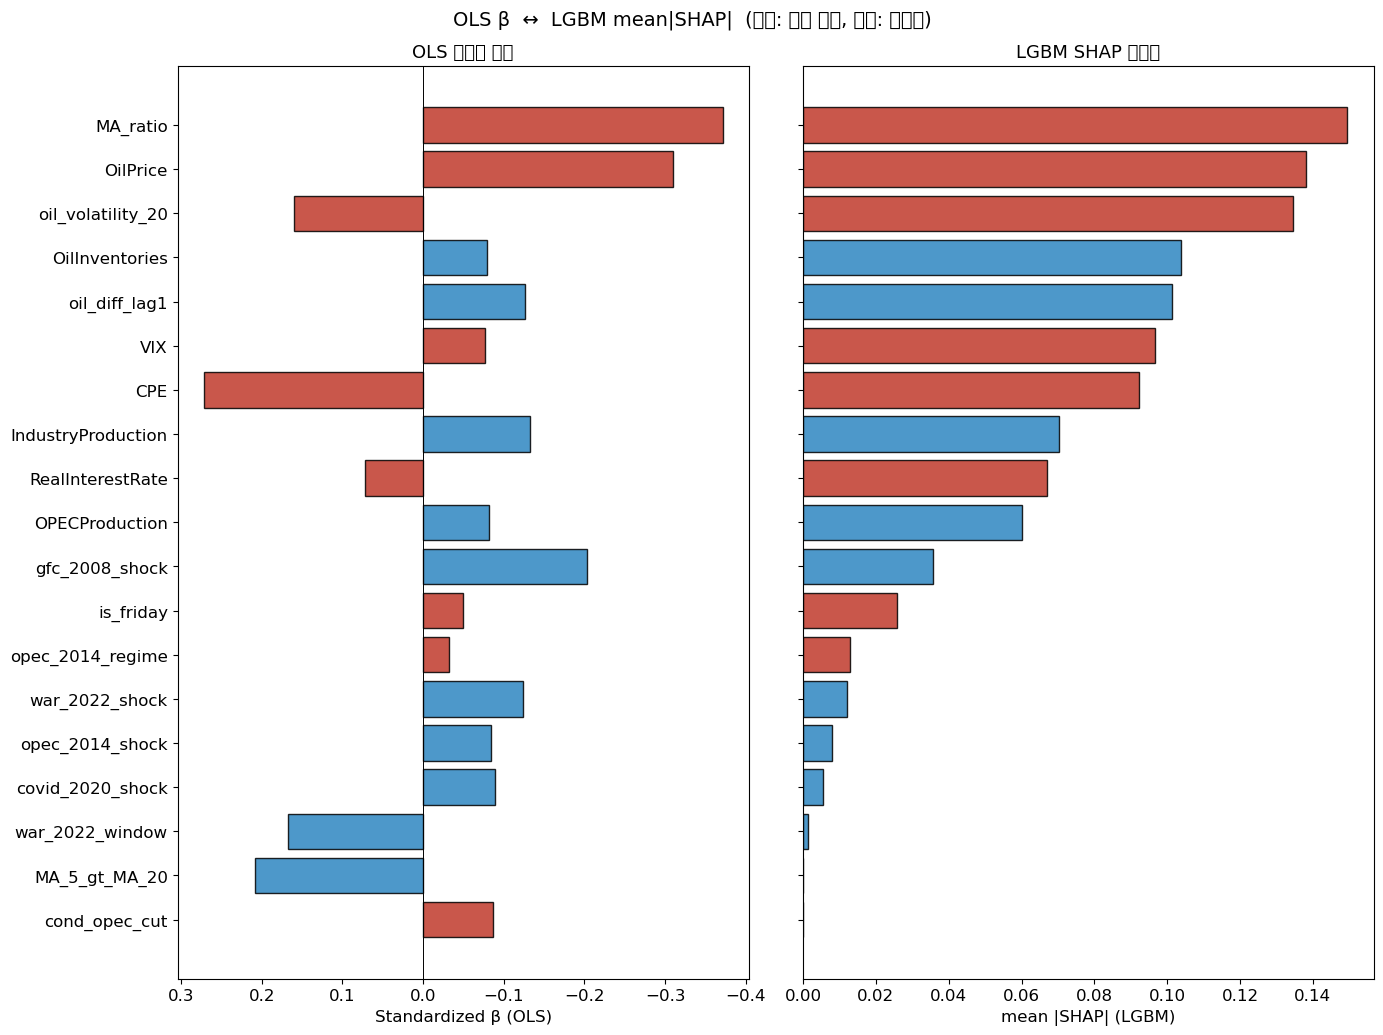

In [10]:
order = cmp.sort_values('mean_abs_shap', ascending=True).reset_index(drop=True)
yloc = np.arange(len(order))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 0.45 * len(order) + 2), sharey=True)

colors = ['#2E86C1' if m else '#C0392B' for m in order['sign_match']]

ax_l.barh(yloc, order['std_beta_OLS'], color=colors, edgecolor='black', alpha=0.85)
ax_l.axvline(0, color='black', lw=0.7)
ax_l.invert_xaxis()
ax_l.set_yticks(yloc)
ax_l.set_yticklabels(order['variable'])
ax_l.set_xlabel('Standardized β (OLS)', fontsize=12)
ax_l.set_title('OLS 표준화 계수', fontsize=13)

ax_r.barh(yloc, order['mean_abs_shap'], color=colors, edgecolor='black', alpha=0.85)
ax_r.set_xlabel('mean |SHAP| (LGBM)', fontsize=12)
ax_r.set_title('LGBM SHAP 중요도', fontsize=13)

fig.suptitle('OLS β  ↔  LGBM mean|SHAP|  (파랑: 부호 일치, 빨강: 불일치)', fontsize=14)
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'paired_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 케이스별 해석 문장 자동 생성

In [11]:
for _, row in cmp.iterrows():
    beta = row['std_beta_OLS']
    p = row['p_HC3']
    mshap = row['mean_abs_shap']
    p_txt = f'p<0.01' if p < 0.01 else (f'p<0.05' if p < 0.05 else f'p={p:.3f}')
    sign_txt = '부호 일치' if row['sign_match'] else '부호 불일치'
    print(f"{row['variable']:25s} | OLS β = {beta:+.4f} ({p_txt}), mean|SHAP| = {mshap:.4f} | {sign_txt} → {row['case']}")

MA_ratio                  | OLS β = -0.3713 (p<0.05), mean|SHAP| = 0.1493 | 부호 불일치 → 상호작용 의심
OilPrice                  | OLS β = -0.3102 (p=0.260), mean|SHAP| = 0.1380 | 부호 불일치 → 순수 비선형 효과
oil_volatility_20         | OLS β = +0.1596 (p=0.204), mean|SHAP| = 0.1345 | 부호 불일치 → 순수 비선형 효과
OilInventories            | OLS β = -0.0797 (p<0.01), mean|SHAP| = 0.1039 | 부호 일치 → 비선형 추가 효과
oil_diff_lag1             | OLS β = -0.1268 (p=0.054), mean|SHAP| = 0.1012 | 부호 일치 → 순수 비선형 효과
VIX                       | OLS β = -0.0762 (p=0.070), mean|SHAP| = 0.0965 | 부호 불일치 → 순수 비선형 효과
CPE                       | OLS β = +0.2720 (p<0.01), mean|SHAP| = 0.0923 | 부호 불일치 → 상호작용 의심
IndustryProduction        | OLS β = -0.1324 (p=0.227), mean|SHAP| = 0.0702 | 부호 일치 → 약한 효과
RealInterestRate          | OLS β = +0.0722 (p<0.05), mean|SHAP| = 0.0671 | 부호 불일치 → 상호작용 의심
OPECProduction            | OLS β = -0.0812 (p=0.347), mean|SHAP| = 0.0601 | 부호 일치 → 약한 효과
gfc_2008_shock            | OLS β = -0.2034 (p<0.05), mean|SHA

## 9. 저장

In [12]:
shap_summary.to_csv(BASELINE_DIR / 'lgbm_shap_summary.csv', index=False)
cmp.to_csv(BASELINE_DIR / 'interpretation_compare.csv', index=False)
np.save(BASELINE_DIR / 'shap_values.npy', shap_arr)

print('저장 완료:')
for f in ['lgbm_shap_summary.csv', 'interpretation_compare.csv', 'shap_values.npy',
          'shap_summary.png', 'shap_summary_bar.png', 'dependence_top5.png', 'paired_importance.png']:
    print(' -', BASELINE_DIR / f)

저장 완료:
 - ../outputs/baseline/lgbm_shap_summary.csv
 - ../outputs/baseline/interpretation_compare.csv
 - ../outputs/baseline/shap_values.npy
 - ../outputs/baseline/shap_summary.png
 - ../outputs/baseline/shap_summary_bar.png
 - ../outputs/baseline/dependence_top5.png
 - ../outputs/baseline/paired_importance.png
